In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_data_imputation.csv')

In [4]:
df.shape

(3555, 18)

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159


### Before doing Feature selection, Floornum and luxury score must be handled since their values are highly inconsistent and needs to be grouped.

### floorNum

<Axes: ylabel='floorNum'>

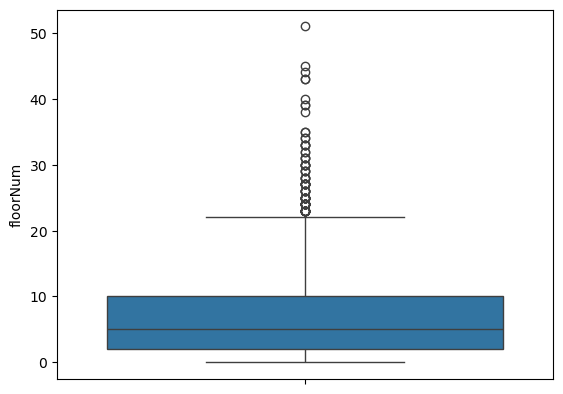

In [6]:
sns.boxplot(df['floorNum'])

In [7]:
def categorize_fllorNum(floor):
    if 0<= floor <= 3:
        return 'Low'
    elif 4 <= floor <= 10:
        return 'Mid'
    else: return 'High'

In [8]:
train_df = df

In [9]:
train_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159


In [10]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_fllorNum)

In [11]:
train_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,floor_category
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8,Low
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38,Mid
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49,High
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174,Mid
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159,Mid


### Luxury score

<Axes: ylabel='luxury_score'>

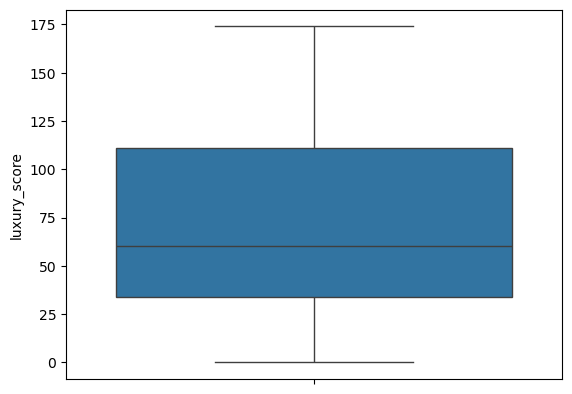

In [12]:
sns.boxplot(df['luxury_score'])

In [13]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [14]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [15]:
train_df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,floor_category,luxury_category
0,flat,signature global park 4,sector 36,0.82,7586.0,3,2,2,2.0,New Property,850.0,0,0,0,0,0,0,8,Low,Low
1,flat,smart world gems,sector 89,0.95,8597.0,2,2,2,4.0,New Property,1226.0,1,1,0,0,0,0,38,Mid,Low
2,flat,breez global hill view,sohna road,0.32,5470.0,2,2,1,17.0,New Property,1000.0,0,0,0,0,0,0,49,High,Low
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3,4,3+,10.0,Relatively New,1615.0,0,1,0,0,1,1,174,Mid,High
4,flat,suncity avenue,sector 102,0.48,9023.0,2,2,1,5.0,Relatively New,582.0,0,0,1,0,0,0,159,Mid,High


## Now we need to remove follwing columns:
### society, price_per_sqft, floorNum, luxury_score
* society, price_per_sqft -> beacuse if user already know these, no point of price prediction.

In [16]:
train_df.drop(columns = ['floorNum', 'society', 'price_per_sqft', 'luxury_score'], inplace = True)

In [17]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,0,Low,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,0,Mid,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,0,High,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,1,Mid,High
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,0,0,0,Mid,High


### Now lets fix categorical columns first

In [18]:
from sklearn.preprocessing import OrdinalEncoder
data_encoded = train_df.copy()
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Applying Label Encoding
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_encoded[col] = oe.fit_transform(data_encoded[[col]])
    print(oe.categories_)

# Splitting the data
x_label = data_encoded.drop('price', axis = 1)
y_label = data_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

In [19]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,0.0,36.0,3,2,2.0,1.0,850.0,0,0,0,0,0,0,1.0,1.0
1,0.0,95.0,2,2,2.0,1.0,1226.0,1,1,0,0,0,0,2.0,1.0
2,0.0,103.0,2,2,1.0,1.0,1000.0,0,0,0,0,0,0,0.0,1.0
3,0.0,99.0,3,4,4.0,3.0,1615.0,0,1,0,0,1,1,2.0,0.0
4,0.0,5.0,2,2,1.0,3.0,582.0,0,0,1,0,0,0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0.0,90.0,2,2,1.0,3.0,532.0,0,0,0,0,0,0,2.0,2.0
3551,1.0,12.0,5,5,4.0,3.0,6228.0,1,1,1,1,0,0,1.0,0.0
3552,0.0,23.0,1,1,1.0,0.0,665.0,0,0,0,0,0,1,2.0,2.0
3553,1.0,44.0,5,6,3.0,0.0,5490.0,1,1,1,1,0,0,1.0,2.0


In [20]:
y_label.head()

0    0.82
1    0.95
2    0.32
3    1.60
4    0.48
Name: price, dtype: float64

## Feature Selection

### 1. Correlation Analysis

<Axes: >

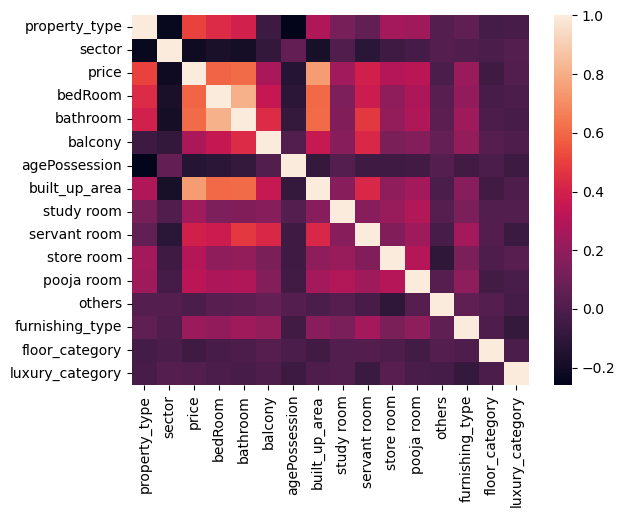

In [21]:
sns.heatmap(data_encoded.corr())

In [22]:
f_df1 = data_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns= {'index':'feature', 'price':'corr_coeff'})

In [23]:
f_df1

,feature,corr_coeff
0,sector,-0.212197
1,price,1.000000
2,bedRoom,0.591352
3,bathroom,0.609836
4,balcony,0.269848
5,agePossession,-0.134394
6,built_up_area,0.748560
7,study room,0.243021
8,servant room,0.392015
9,store room,0.305712


### 2. Random Forest Feature Importance

In [24]:
from sklearn.ensemble import RandomForestRegressor
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(x_label, y_label)

f_df2 = pd.DataFrame({
    'feature': x_label.columns,
    'rf_imp': rf_label.feature_importances_
}).sort_values(by='rf_imp', ascending = False)

f_df2

,feature,rf_imp
6,built_up_area,0.647140
1,sector,0.107905
0,property_type,0.100471
2,bedRoom,0.024995
3,bathroom,0.023930
8,servant room,0.018964
5,agePossession,0.014879
4,balcony,0.012021
12,furnishing_type,0.009663
7,study room,0.009261


### 3. Gradient Boosting Feature Importance

In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(x_label, y_label)

f_df3 = pd.DataFrame({
    'feature' : x_label.columns,
    'gb_imp' : gb_label.feature_importances_
}).sort_values(by = 'gb_imp', ascending = False)

f_df3

,feature,gb_imp
6,built_up_area,0.679981
1,sector,0.102514
0,property_type,0.096928
2,bedRoom,0.036785
3,bathroom,0.034301
8,servant room,0.022602
9,store room,0.009217
7,study room,0.004402
5,agePossession,0.004042
13,floor_category,0.003277


### 4. Permutation Importance
It basically removes and add random rows or columns and chech how do model suffers in their absence. Thus giving Columns their importance values.

In [28]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_label, y_label, test_size=0.2, random_state=42)

rf_label =  RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(x_train, y_train)

perm_imp = permutation_importance(rf_label, x_test, y_test, n_repeats= 32, random_state=42)

f_df4 = pd.DataFrame({
    'feature' : x_label.columns,
    'perm_imp' : perm_imp.importances_mean
}).sort_values(by = 'perm_imp', ascending = False)

f_df4

,feature,perm_imp
6,built_up_area,0.720212
0,property_type,0.204951
1,sector,0.164544
8,servant room,0.021285
3,bathroom,0.018779
2,bedRoom,0.017800
5,agePossession,0.008661
13,floor_category,0.007027
14,luxury_category,0.003315
7,study room,0.002386


### 5. RFE (Recursive Feature Elimination)
It basically starts with all features and then remove them one by one.

In [30]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=x_label.shape[1], step=1)
selector_label = selector_label.fit(x_label, y_label)

# Get the selected features based on RFE
selected_features = x_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
f_df5 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

f_df5

,feature,rfe_score
6,built_up_area,0.647596
1,sector,0.105413
0,property_type,0.100264
3,bathroom,0.028431
2,bedRoom,0.024163
8,servant room,0.018189
5,agePossession,0.014223
4,balcony,0.012229
13,floor_category,0.009666
12,furnishing_type,0.009582


### 6. LASSO
Since we did ordinal encoding, features with high no. of categories are going down (because it give categories no.) and since its Linear model, cant expect good result in this specific case for high cardinality features.

In [31]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(x_scaled, y_label)

# Extract coefficients
f_df6 = pd.DataFrame({
    'feature': x_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

f_df6

,feature,lasso_coeff
6,built_up_area,1.507767
0,property_type,0.712842
3,bathroom,0.275968
9,store room,0.199975
7,study room,0.172467
12,furnishing_type,0.163995
8,servant room,0.161476
10,pooja room,0.072515
14,luxury_category,0.054934
2,bedRoom,0.013471


### Since most of the work is done, lets settle things...

In [33]:
final_fi_df = f_df1.merge(f_df2, on='feature').merge(f_df3, on= 'feature').merge(f_df4, on= 'feature').merge(f_df5, on= 'feature').merge(f_df6, on= 'feature').set_index('feature')

In [34]:
final_fi_df

,corr_coeff,rf_imp,gb_imp,perm_imp,rfe_score,lasso_coeff
feature,,,,,,
sector,-0.212197,0.107905,0.102514,0.164544,0.105413,-0.070454
bedRoom,0.591352,0.024995,0.036785,0.017800,0.024163,0.013471
bathroom,0.609836,0.023930,0.034301,0.018779,0.028431,0.275968
balcony,0.269848,0.012021,0.002063,0.000644,0.012229,-0.042220
agePossession,-0.134394,0.014879,0.004042,0.008661,0.014223,-0.000000
built_up_area,0.748560,0.647140,0.679981,0.720212,0.647596,1.507767
study room,0.243021,0.009261,0.004402,0.002386,0.007669,0.172467
servant room,0.392015,0.018964,0.022602,0.021285,0.018189,0.161476
store room,0.305712,0.008092,0.009217,-0.002770,0.005678,0.199975


In [35]:
# Normalizing the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis = 0), axis = 1)

In [36]:
final_fi_df[['rf_imp','gb_imp','perm_imp','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.735093
sector             0.130394
bathroom           0.028923
bedRoom            0.028467
servant room       0.022110
agePossession      0.011456
floor_category     0.007923
balcony            0.007477
furnishing_type    0.006625
study room         0.006543
store room         0.005659
luxury_category    0.004817
pooja room         0.002694
others             0.001819
dtype: float64

#### Hence, buit_up_area and sector are the most important as expected. pooja_room and others are least important and thus can be removed.
#### Lets check it.

In [38]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label, y_label, cv=5, scoring='r2')

In [39]:
scores.mean()

np.float64(0.8190281826625398)

In [41]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label.drop(columns=['pooja room', 'others']), y_label, cv=5, scoring='r2')

In [42]:
scores.mean()

np.float64(0.8214492070318782)

In [44]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, x_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [45]:
scores.mean()

np.float64(0.8205561936495332)

* Thus after dropping pooja room and others columns, r2 score increased. 
* But when we dropped study room (which was shown as important) score slighly decreased.
* Thus our observations are correct and pooja room and others columns can be dropped.

In [51]:
df

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,0,Low,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,0,Mid,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,0,High,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,1,Mid,High
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,0,0,0,Mid,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,flat,sector 84,0.37,2,2,1,Relatively New,532.0,0,0,0,0,0,0,Mid,Medium
3551,house,sector 109,6.00,5,5,3+,Relatively New,6228.0,1,1,1,1,0,0,Low,High
3552,flat,sector 2,0.60,1,1,1,Moderately Old,665.0,0,0,0,0,0,1,Mid,Medium
3553,house,sector 43,15.50,5,6,3,Moderately Old,5490.0,1,1,1,1,0,0,Low,Medium


In [52]:
df['furnishing_type'].value_counts()

furnishing_type
0    2350
1    1018
2     187
Name: count, dtype: int64

In [53]:
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished
df['furnishing_type'] = df['furnishing_type'].replace({0:'unfurnished',1:'semifurnished',2:'furnished'})

In [54]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,0,0,unfurnished,Low,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,0,0,unfurnished,Mid,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,0,0,unfurnished,High,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,0,1,semifurnished,Mid,High
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,0,0,unfurnished,Mid,High


In [55]:
df = df.drop(columns = ['pooja room', 'others'])

In [56]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,furnishing_type,floor_category,luxury_category
0,flat,sector 36,0.82,3,2,2,New Property,850.0,0,0,0,unfurnished,Low,Low
1,flat,sector 89,0.95,2,2,2,New Property,1226.0,1,1,0,unfurnished,Mid,Low
2,flat,sohna road,0.32,2,2,1,New Property,1000.0,0,0,0,unfurnished,High,Low
3,flat,sector 92,1.60,3,4,3+,Relatively New,1615.0,0,1,0,semifurnished,Mid,High
4,flat,sector 102,0.48,2,2,1,Relatively New,582.0,0,0,1,unfurnished,Mid,High


In [57]:
df.to_csv('gurgaon_feature_selection.csv', index = False)